In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing import image
import os
from os import listdir
import csv
import natsort 

In [3]:
# Path to the directory containing the dataset
# CHANGE THIS PATH TO THE DIRECTORY ON YOUR GOOGLE DRIVE (if you use Colab)
# Note that the folder with the data is a zipped (compressed) folder
!unzip -uq 'drive/My Drive/Colab Notebooks/AML Course/Fall 2021/Datasets/LFW-dataset.zip' -d 'sample_data/'

# The images were obtained from https://github.com/telecombcn-dl/2018-dlai-team4
# This is a subset of the original FLW dataset, called "optimized for accuracy"
# The subset is based only on celebrities with more than 20 images in FLW
# And also, a preprocessing step is applied to extract only the face from the whole images

In [4]:
# Function for loading the images
def load_imgs(path):
    # List of all images in the folder
    imgList = listdir(path)
    # Make sure that the images are sorted in ascending order
    imgList=natsort.natsorted(imgList)
    # Number of images
    number_imgs = len(imgList)
    # Initialize numpy arrays for the images
    images = np.zeros((number_imgs, image_size, image_size, 3))
    # Read the images
    for i in range(number_imgs):
        tmp_img = image.load_img(path + imgList[i], target_size=(image_size, image_size, 3))
        img = image.img_to_array(tmp_img)
        images[i] = img/255.0
    return images

In [5]:
# Directories
train_dir = 'sample_data/LFW-dataset/Train/'
test_dir = 'sample_data/LFW-dataset/Test/'
val_dir = 'sample_data/LFW-dataset/Validation/'
labels_dir = 'sample_data/LFW-dataset/'

# Size
image_size = 100

# Load the images as numpy arrays
imgs_train = load_imgs(train_dir)
imgs_test = load_imgs(test_dir)
imgs_val = load_imgs(val_dir)

# Load the labels as numpy arrays
labels_train = np.genfromtxt(labels_dir + "train_labels.csv", delimiter=',', dtype=np.int32)
labels_test = np.genfromtxt(labels_dir + "test_labels.csv", delimiter=',', dtype=np.int32)
labels_val = np.genfromtxt(labels_dir + "val_labels.csv", delimiter=',', dtype=np.int32)

In [6]:
# Display the shapes of train, validation, and test datasets
print('Images train shape: {} - Labels train shape: {}'.format(imgs_train.shape, labels_train.shape))
print('Images validation shape: {} - Labels validation shape: {}'.format(imgs_val.shape, labels_val.shape))
print('Images test shape: {} - Labels test shape: {}'.format(imgs_test.shape, labels_test.shape))

# Display the range of images (to make sure they are in the [0, 1] range)
print('\nMax pixel value', np.max(imgs_train))
print('Min pixel value', np.min(imgs_train))
print('Average pixel value', np.mean(imgs_train))
print('Data type', imgs_train[0].dtype)

Images train shape: (3043, 100, 100, 3) - Labels train shape: (3043,)
Images validation shape: (1021, 100, 100, 3) - Labels validation shape: (1021,)
Images test shape: (1049, 100, 100, 3) - Labels test shape: (1049,)

Max pixel value 1.0
Min pixel value 0.0
Average pixel value 0.4739037699151936
Data type float64


In [7]:
# Create a list with the names of the celebrities in the dataset (there are 62 celebrities)
name_list = []
with open(labels_dir+'name_list.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        name_list.append(row[1])

# Ignore the top row in the table
name_list = name_list[1:]
print(name_list)

['Gloria_Macapagal_Arroyo', 'Jennifer_Capriati', 'Laura_Bush', 'Winona_Ryder', 'Tiger_Woods', 'Hugo_Chavez', 'John_Negroponte', 'George_W_Bush', 'Roh_Moo-hyun', 'Paul_Bremer', 'George_Robertson', 'Tom_Daschle', 'Ricardo_Lagos', 'Jennifer_Lopez', 'Jose_Maria_Aznar', 'Silvio_Berlusconi', 'Vicente_Fox', 'Jennifer_Aniston', 'Gerhard_Schroeder', 'David_Beckham', 'Kofi_Annan', 'Igor_Ivanov', 'Jiang_Zemin', 'Mahmoud_Abbas', 'Pete_Sampras', 'Guillermo_Coria', 'Donald_Rumsfeld', 'Megawati_Sukarnoputri', 'Jeremy_Greenstock', 'Junichiro_Koizumi', 'Jack_Straw', 'Rudolph_Giuliani', 'Jacques_Chirac', 'Saddam_Hussein', 'John_Ashcroft', 'Lindsay_Davenport', 'Naomi_Watts', 'Lleyton_Hewitt', 'Hamid_Karzai', 'Tom_Ridge', 'Recep_Tayyip_Erdogan', 'Tony_Blair', 'Hans_Blix', 'Jean_Chretien', 'Nestor_Kirchner', 'Gray_Davis', 'Michael_Bloomberg', 'Luiz_Inacio_Lula_da_Silva', 'Juan_Carlos_Ferrero', 'Vladimir_Putin', 'Serena_Williams', 'Alejandro_Toledo', 'Alvaro_Uribe', 'Amelie_Mauresmo', 'Andre_Agassi', 'Angel

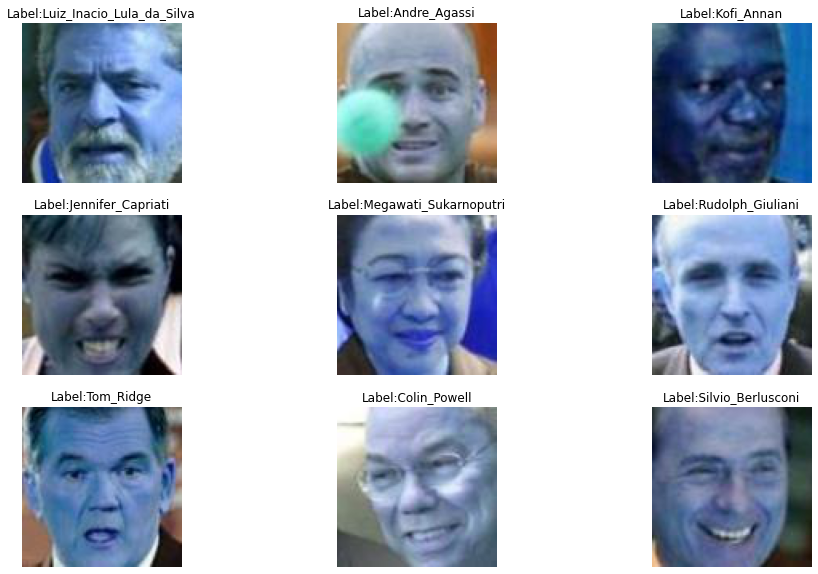

In [8]:
# Plot a few images to check if the the labels are correct
# There are a few bad images in the dataset, it needs to be cleaned a little, but we won't worry about it now
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(imgs_train), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(imgs_train[i[0]])
    plt.title('Label:' + str(name_list[labels_train[i[0]]]))
    plt.axis('off')

In [9]:
# Set constants 
NUM_LABELS = 62                             # Number of labels
BATCH_SIZE = 32                             # Size of batch
INPUT_SHAPE = (image_size, image_size, 3)   # Input shape of model

# Set training hyperparameters
NUM_EPOCH = 50                              # Number of epoch to train
LR = 1e-4                                   # Learning rate

OUTPUT_DIM = 1                             # Number of output dimensions
# Note the difference
# If OUTPUT_DIM = 1, then use: loss = 'sparse_categorical_crossentropy'

# if OUTPUT_DIM = 62, then convert the labels to one-hot vectors (e.g., labels_train = keras.utils.to_categorical(labels_train, NUM_LABELS))
# and use: loss = 'categorical_crossentropy'

In [10]:
# Creating adversarial test sets of 100 images

# Define a random seed (to draw the same images)
np.random.seed(2)

ind = np.random.randint(1, 1000, 100)

# Set of image for testing the attacks
adv_test_imgs = imgs_test[ind]
adv_test_labels = labels_test[ind]

##############################################
# Creating adversarial train sets of images

# Set of images for training the detector with FGSM
adv_train_imgs_fgsm = imgs_train
adv_train_labels_fgsm = labels_train

# Set of images for training the detector with PGD
pgd_ind = np.random.randint(1, 3000, 1000)
adv_train_imgs_pgd = imgs_train[pgd_ind]
adv_train_labels_pgd = labels_train[pgd_ind]

# Set of images for training the detector with DeepFool
df_ind = np.random.randint(1, 3000, 100)
adv_train_imgs_df = imgs_train[df_ind]
adv_train_labels_df = labels_train[df_ind]

##############################################
# The image to use for clarifai
clarifai_img = np.expand_dims(imgs_test[980], axis=0)
# Note that we needed to use expand_dims to make the shape (1,100,100,3)
# So that the array will be a batch size with one image